In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

c:\Users\nasta\anaconda3\envs\ssp_metamodel_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [2]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [3]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v5.4.csv") #NOTE: update filename as needed
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_frac_fgtv_reduction_in_fugitive_leaks,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,0.073998,0.692822,0.979482,0.051058,0.188261,0.581816,0.698145,0.216501,0.371199,0.101867,...,0.792661,0.700647,134.250713,4713.726381,1.127682e+09,1.324550e+10,-65.994098,29.969679,9.915746e+04,2.216441e+06
1,0.425023,0.729207,0.384489,0.436918,0.621826,0.168596,0.725935,0.167295,0.723122,0.186405,...,0.031865,0.682710,164.387644,5168.255434,9.397040e+08,1.365343e+10,-216.578174,21.848342,5.918128e+05,4.092001e+06
2,0.881846,0.761554,0.325130,0.205597,0.237030,0.682775,0.718216,0.452701,0.761919,0.602002,...,0.578509,0.348348,104.151002,4411.805579,8.245545e+08,1.338608e+10,-111.173239,34.271613,2.629557e+05,3.423819e+06
3,0.075106,0.542313,0.668099,0.577434,0.767079,0.804253,0.966784,0.248884,0.082841,0.381400,...,0.536350,0.855946,157.680453,5094.995066,9.153718e+08,1.391765e+10,-307.942260,21.088306,1.202691e+06,3.974195e+06
4,0.057338,0.477879,0.866591,0.161689,0.282495,0.282664,0.310182,0.991945,0.953932,0.864061,...,0.048358,0.042901,187.314145,5488.927406,9.188784e+08,1.169421e+10,-176.019913,27.938870,5.447325e+05,2.886125e+06


## EDA

In [4]:
edau = EDAUtils()

In [5]:
target_cols = [col for col in training_df.columns if not(col.startswith("group_"))]
target_cols

['emission_avg_last_five_years',
 'emission_total',
 'production_total',
 'production_cost_total',
 'technical_cost',
 'air_pollution',
 'num_jobs',
 'earning_per_job']

In [6]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha',
 'group_2_frac_agrc_agriculture_production_lost',
 'group_3_frac_agrc',
 'group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture',
 'group_5_nemomod_entc_frac_min_share_production_fp_hydrogen',
 'group_6_nemomod_en',
 'group_7_frac_fgtv_reduction_in_fugitive_leaks',
 'group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel',
 'group_9_efficfactor_enfu_industrial_energy_fuel',
 'group_10_scalar_inen_energy_demand',
 'group_11_frac_inen_energy',
 'group_12_frac_ippu_cement_clinker',
 'group_13_ef_ippu_tonne_c',
 'group_14_ef_ippu_tonne_n2o_per',
 'group_15_ef_ippu_tonne_c',
 'group_16_pij_lndu',
 'group_17_frac_lndu_improved_pastures',
 'group_18_lndu_reallocation_factor',
 'group_19_gasrf_lsmm_biogas_anaerobic',
 'group_20_frac_lvst_mm',
 'group_21_frac_lvst_mm',
 'group_22_frac_lvst_mm_chickens',
 'group_23_ef_lvst_entferm',
 'group_24_frac_gnrl_eating_red_meat',
 'group_25_frac_ippu_production_with_co2_capture',
 'group_26_scalar

In [7]:
training_df[target_cols].describe()

,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
count,963.000000,963.000000,9.630000e+02,9.630000e+02,963.000000,963.000000,9.630000e+02,9.630000e+02
mean,144.973345,4932.173035,8.983011e+08,1.340526e+10,-170.239915,20.457366,5.678336e+05,3.810548e+06
std,29.413401,403.776245,1.025307e+08,9.498129e+08,57.398582,8.482213,2.502274e+05,4.507335e+06
min,-10.475430,1146.940292,6.896729e+08,1.121025e+10,-394.218207,-5.233689,-8.110885e+05,-7.890726e+07
25%,125.338062,4680.694686,8.127481e+08,1.274130e+10,-205.787701,14.526838,3.966696e+05,3.721246e+06
50%,144.215331,4912.475266,8.909734e+08,1.331771e+10,-169.165482,20.956383,5.590992e+05,3.975150e+06
75%,164.749486,5199.946870,9.743361e+08,1.405272e+10,-132.345125,26.489834,7.259548e+05,4.213223e+06
max,230.334810,6033.346162,1.187387e+09,1.605675e+10,265.105084,43.701492,1.675362e+06,7.505359e+07


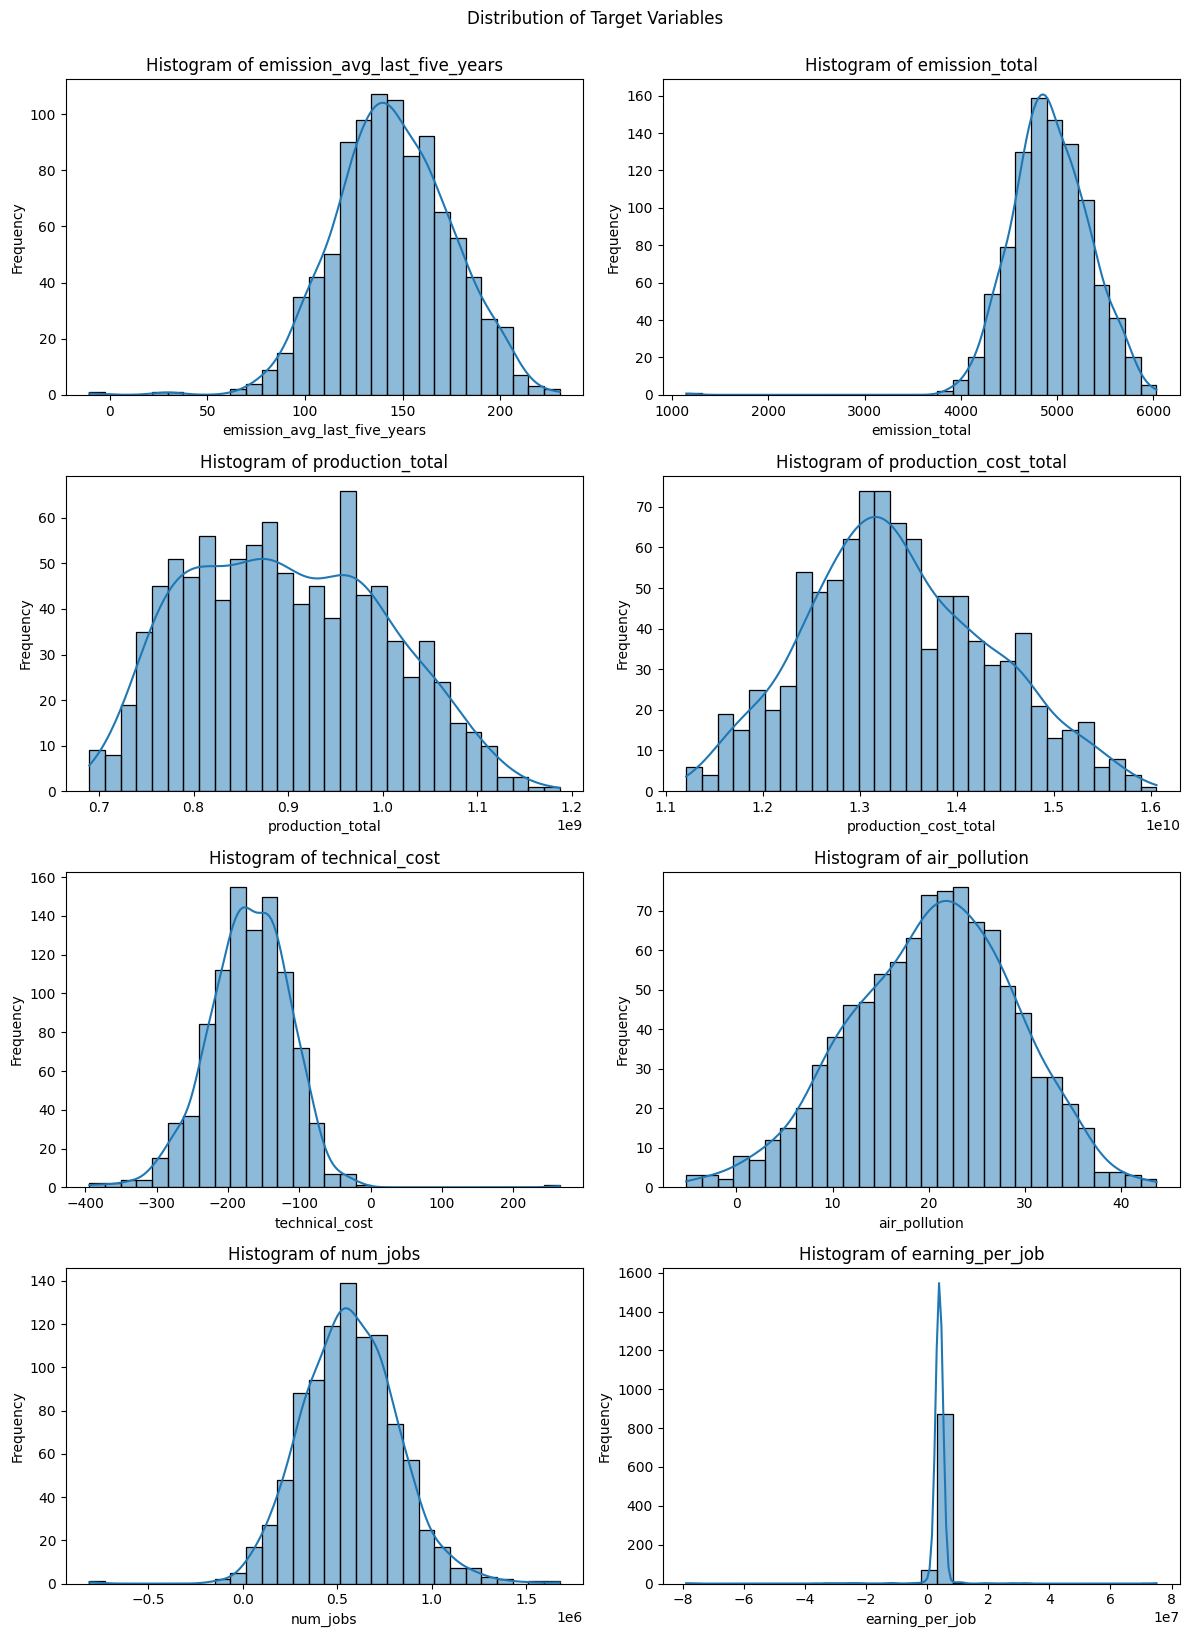

In [8]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")

In [9]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "num_jobs", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "earning_per_job", exclude_cols=target_cols)
	


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6403
group_51_exports_enfu_pj_fuel  : 0.5481
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2244
group_7_frac_fgtv_reduction_in_fugitive_leaks : 0.1750
group_11_frac_inen_energy      : 0.1455
group_57_elasticity_ippu       : 0.1346
group_56_elasticity_trde_pkm_to_gdppc : 0.1112
group_31_demscalar_trde        : 0.1105
group_52_gdp_mmm_usd           : 0.1076


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6550
group_51_exports_enfu_pj_fuel  : 0.5507
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2398
group_7_frac_fgtv_reduction_in_fugitive_leaks : 0.1959
group_57_elasticity_ippu       : 0.1554
group_56_elasticity_trde_pkm_to_gdppc : 0.1423
group_31_demscalar_trde      

In [12]:
# Find constant / near-constant cols
# const_cols = edau.find_constant_columns(training_df)
# near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
# print("Constant:", const_cols)
# print("Near-constant:", near_const_cols)

In [10]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_avg_last_five_years': 0.52, 'emission_total': 0.52, 'production_cost_total': 0.1, 'technical_cost': 1.14, 'air_pollution': 0.31, 'num_jobs': 1.14, 'earning_per_job': 9.66}


## Data Cleaning

In [11]:
dcu = DataCleaningUtils()

In [12]:
training_df.shape

(963, 66)

In [16]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [17]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [13]:

training_df_cleaned = dcu.remove_outliers(training_df, method="iqr", factor=1.5)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (963, 66)
Shape after removing outliers: (851, 66)


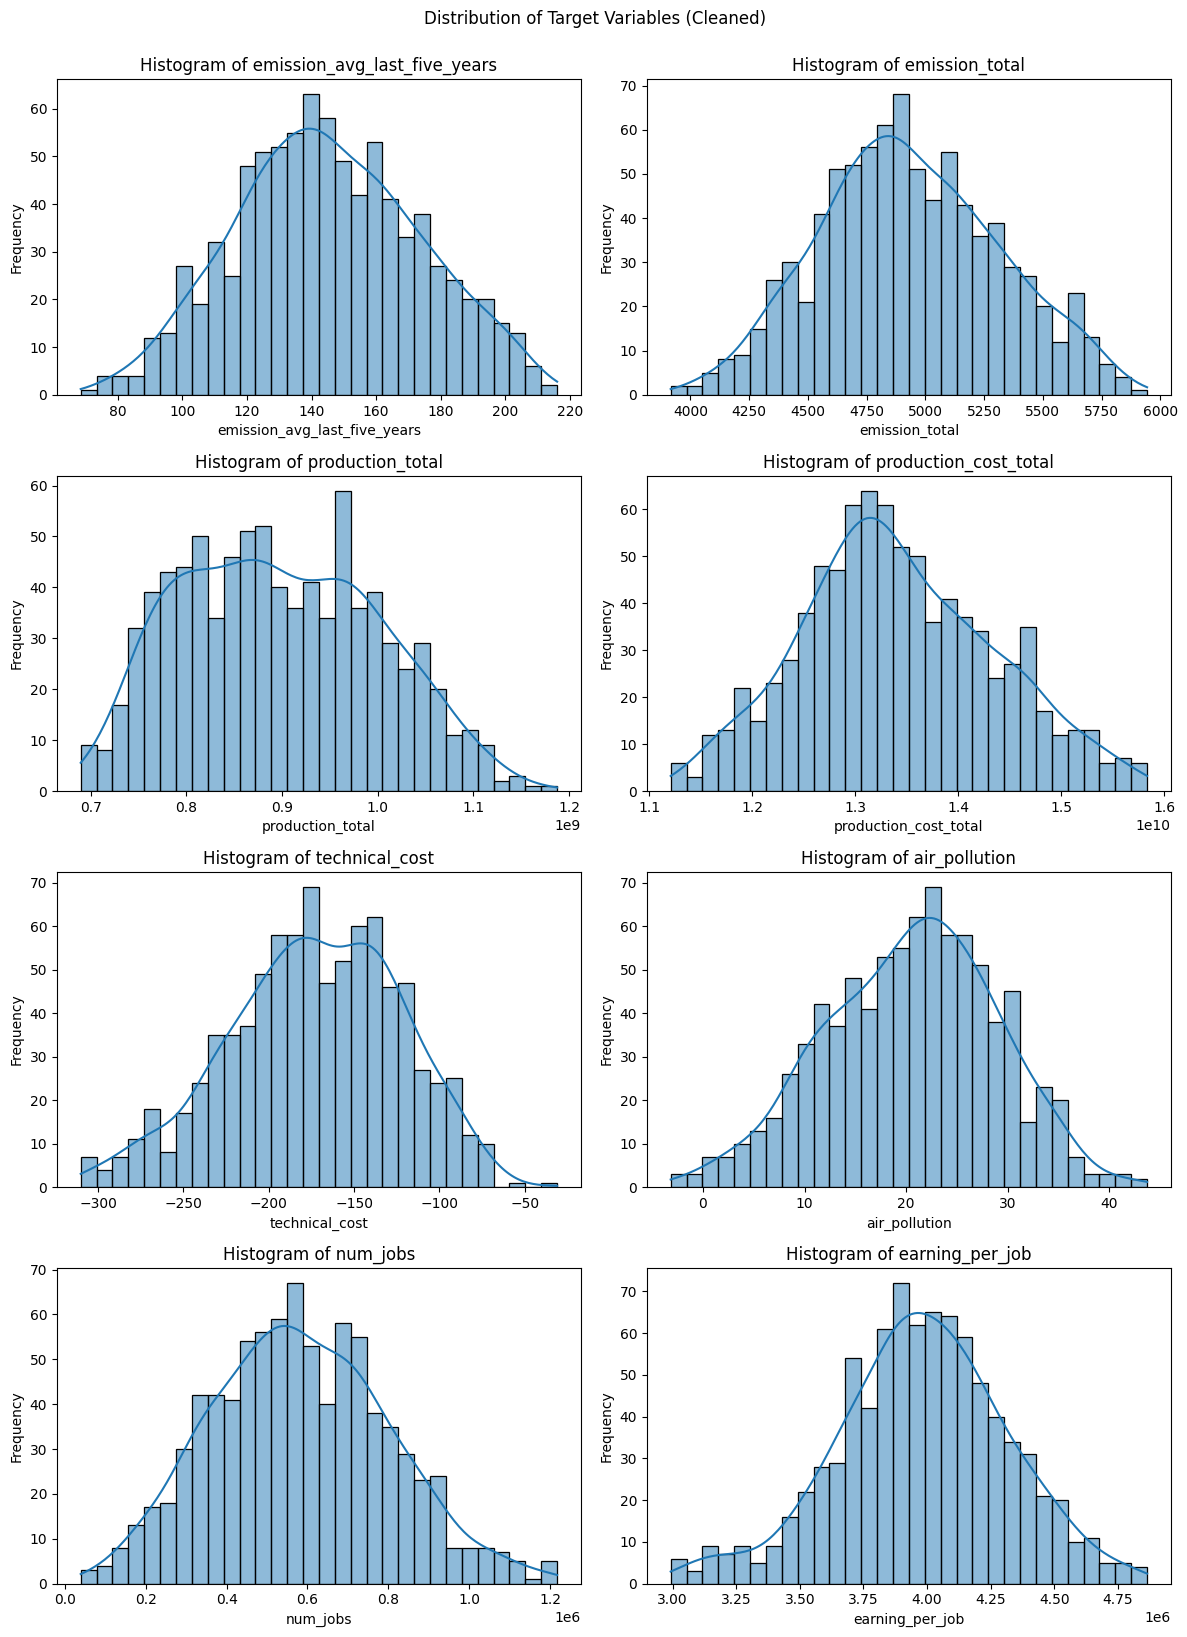

In [14]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [15]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {}


In [16]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "num_jobs", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "earning_per_job", exclude_cols=target_cols)


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6403
group_51_exports_enfu_pj_fuel  : 0.5481
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2244
group_7_frac_fgtv_reduction_in_fugitive_leaks : 0.1750
group_11_frac_inen_energy      : 0.1455
group_57_elasticity_ippu       : 0.1346
group_56_elasticity_trde_pkm_to_gdppc : 0.1112
group_31_demscalar_trde        : 0.1105
group_52_gdp_mmm_usd           : 0.1076


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6550
group_51_exports_enfu_pj_fuel  : 0.5507
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2398
group_7_frac_fgtv_reduction_in_fugitive_leaks : 0.1959
group_57_elasticity_ippu       : 0.1554
group_56_elasticity_trde_pkm_to_gdppc : 0.1423
group_31_demscalar_trde      

In [17]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
count,851.000000,851.000000,8.510000e+02,8.510000e+02,851.000000,851.000000,8.510000e+02,8.510000e+02
mean,145.064397,4933.441656,8.972666e+08,1.341613e+10,-173.076161,20.487950,5.827280e+05,3.976721e+06
std,28.556845,382.974617,1.026929e+08,9.391695e+08,50.309898,8.389477,2.194914e+05,3.396369e+05
min,68.477202,3916.183111,6.896729e+08,1.121025e+10,-310.204144,-3.168143,3.906509e+04,2.992566e+06
25%,124.946192,4670.062268,8.122271e+08,1.277832e+10,-206.219446,14.526838,4.299248e+05,3.765911e+06
50%,144.060415,4906.725193,8.893463e+08,1.332259e+10,-171.856259,21.018528,5.719571e+05,3.982495e+06
75%,164.854487,5195.417791,9.720883e+08,1.405173e+10,-136.569556,26.380412,7.284119e+05,4.200354e+06
max,216.113864,5943.360990,1.187387e+09,1.583394e+10,-31.015009,43.701492,1.217449e+06,4.865162e+06


In [24]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [25]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [26]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [27]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [28]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB hyperparameters: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}

=== XGB ===
emission_avg_last_five_years  
  Train → MAE: 1.1975, RMSE: 1.4980, R²: 0.9972, SMAPE: 0.9%
   Test → MAE: 5.9009, RMSE: 7.4299, R²: 0.9327, SMAPE: 4.2%
emission_total                
  Train → MAE: 14.0840, RMSE: 17.7563, R²: 0.9979, SMAPE: 0.3%
   Test → MAE: 71.5116, RMSE: 88.1926, R²: 0.9462, SMAPE: 1.5%
production_total              
  Train → MAE: 2143732.4501, RMSE: 2697448.9659, R²: 0.9993, SMAPE: 0.2%
   Test → MAE: 8702116.3683, RMSE: 11261747.0400, R²: 0.9864, SMAPE: 1.0%
production_cost_total         
  Train → MAE: 18413486.1509, RMSE: 23175652.0470, R²: 0.9994, SMAPE: 0.1%
   Test → MAE: 64442511.1999, RMSE: 81364423.7297, R²: 0.9928, SMAPE: 0.5%
technical_cost                
  Train → MAE: 2.8417, RMSE: 3.5965, R²: 0.9950, SMAPE: 1.8

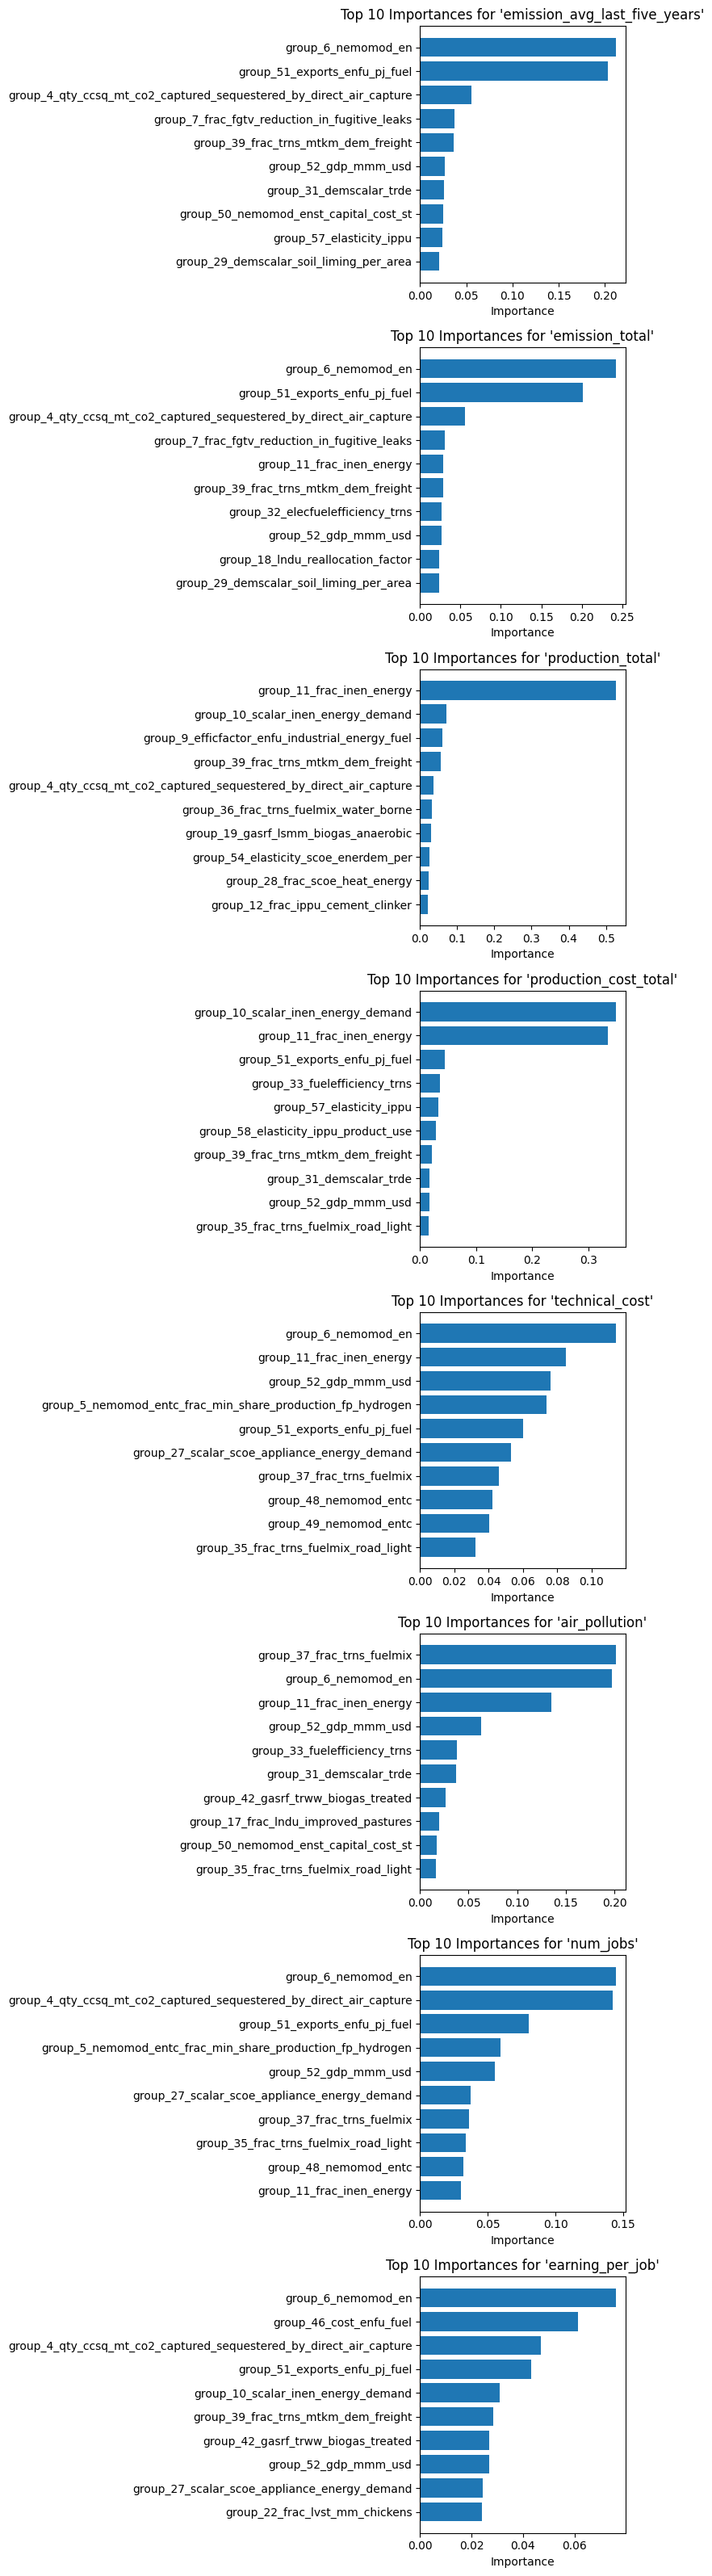

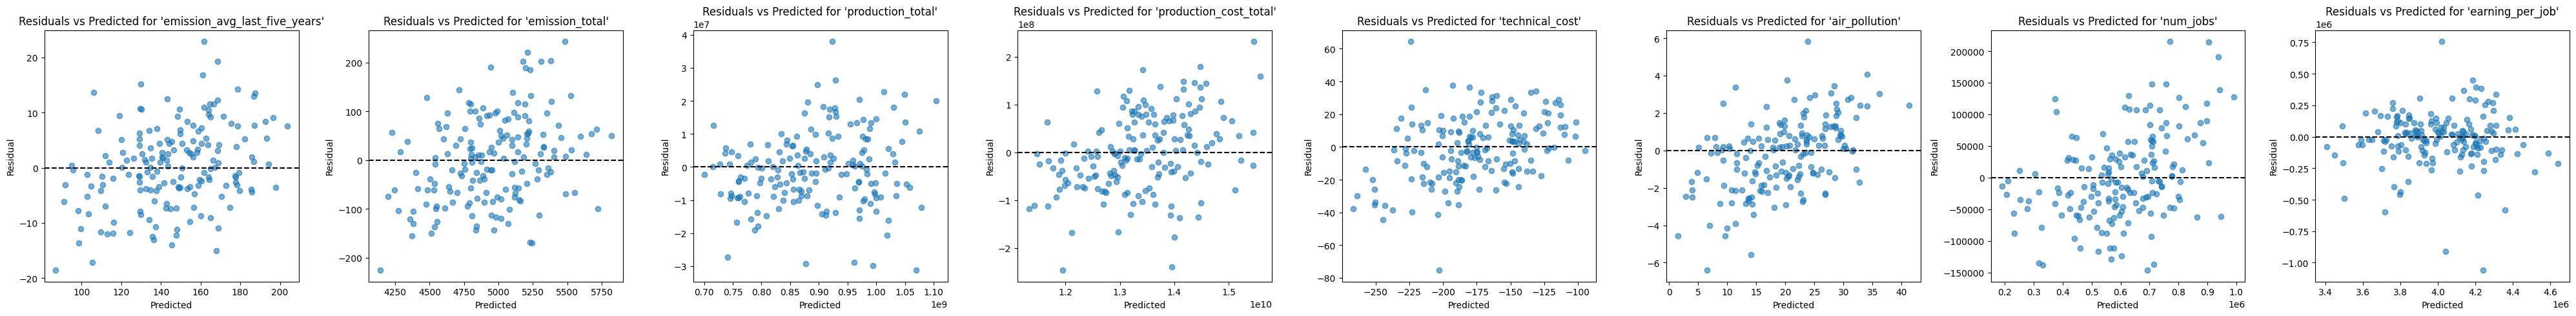

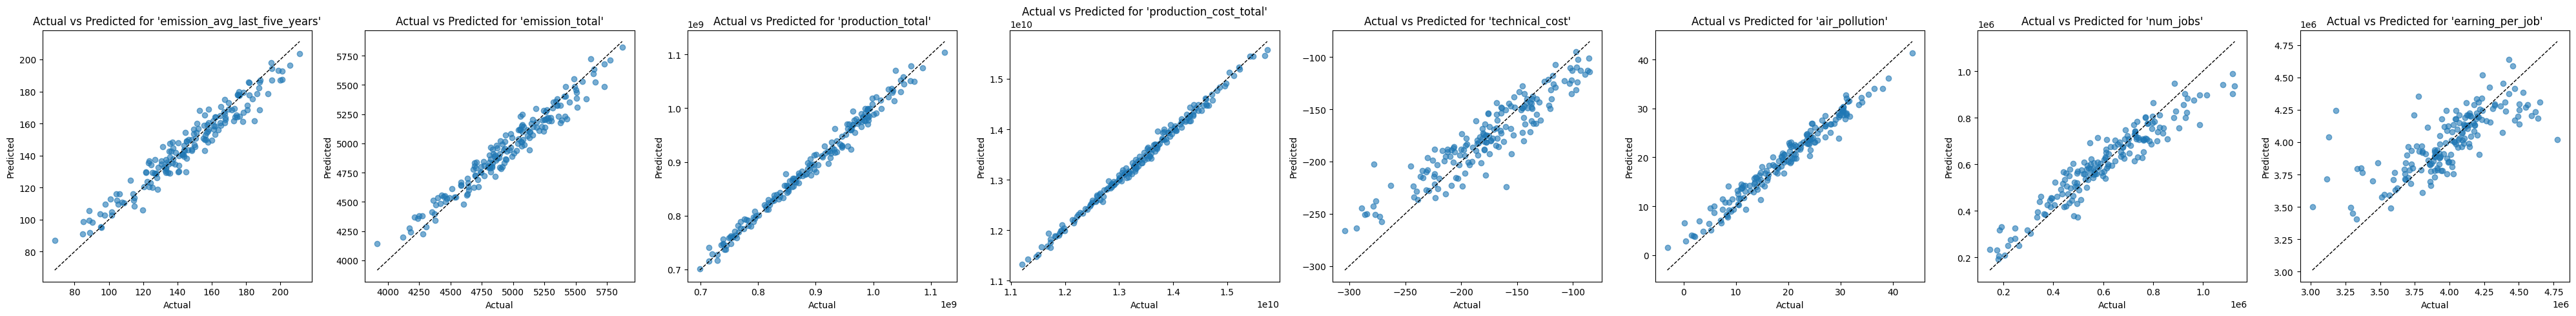

In [18]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=target_cols)
mulp.run(tune=True, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [19]:
training_df_cleaned.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_frac_fgtv_reduction_in_fugitive_leaks,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
1,0.425023,0.729207,0.384489,0.436918,0.621826,0.168596,0.725935,0.167295,0.723122,0.186405,...,0.031865,0.682710,164.387644,5168.255434,9.397040e+08,1.365343e+10,-216.578174,21.848342,5.918128e+05,4.092001e+06
2,0.881846,0.761554,0.325130,0.205597,0.237030,0.682775,0.718216,0.452701,0.761919,0.602002,...,0.578509,0.348348,104.151002,4411.805579,8.245545e+08,1.338608e+10,-111.173239,34.271613,2.629557e+05,3.423819e+06
3,0.075106,0.542313,0.668099,0.577434,0.767079,0.804253,0.966784,0.248884,0.082841,0.381400,...,0.536350,0.855946,157.680453,5094.995066,9.153718e+08,1.391765e+10,-307.942260,21.088306,1.202691e+06,3.974195e+06
5,0.511133,0.698963,0.711505,0.683995,0.437127,0.227332,0.355119,0.640986,0.844816,0.833615,...,0.256756,0.677597,154.259184,5011.043324,9.229118e+08,1.212730e+10,-136.322191,19.634602,3.448604e+05,4.380523e+06
6,0.056536,0.347037,0.601926,0.250927,0.025473,0.233382,0.982949,0.616953,0.602104,0.128246,...,0.297084,0.254122,124.806708,4673.230701,7.505162e+08,1.554105e+10,-153.063682,10.965906,3.024828e+05,4.130726e+06


In [20]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(target_cols)
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_frac_fgtv_reduction_in_fugitive_leaks,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_49_nemomod_entc,group_50_nemomod_enst_capital_cost_st,group_51_exports_enfu_pj_fuel,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use
1,0.425023,0.729207,0.384489,0.436918,0.621826,0.168596,0.725935,0.167295,0.723122,0.186405,...,0.685731,0.370917,0.299382,0.979554,0.495744,0.973614,0.134799,0.86236,0.031865,0.68271


In [21]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)
print("Original values:")
print(training_df_cleaned.iloc[0][target_cols])

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
1                    162.268921     5162.081543       943812800.0   

   production_cost_total  technical_cost  air_pollution    num_jobs  \
1           1.364527e+10     -213.698425      21.741123  575332.625   

   earning_per_job  
1        4196477.5  
Original values:
emission_avg_last_five_years    1.643876e+02
emission_total                  5.168255e+03
production_total                9.397040e+08
production_cost_total           1.365343e+10
technical_cost                 -2.165782e+02
air_pollution                   2.184834e+01
num_jobs                        5.918128e+05
earning_per_job                 4.092001e+06
Name: 1, dtype: float64


In [23]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.4.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)
overwrite_existing_model = True  # Set to True to overwrite existing model

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH) and not overwrite_existing_model:
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.4.pkl to e:\Current_2023\WI\work\ssp_louisiana\metamodel\notebooks\trained_models\xgb_pipeline_5.4.pkl.


In [24]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [25]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
1                    162.268921     5162.081543       943812800.0   

   production_cost_total  technical_cost  air_pollution    num_jobs  \
1           1.364527e+10     -213.698425      21.741123  575332.625   

   earning_per_job  
1        4196477.5  


In [29]:
from pathlib import Path
TRAINED_MODELS_DIR = Path(TRAINED_MODELS_DIR)
mulp.X_test.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.4_x_test.parquet")
mulp.y_test.to_parquet(TRAINED_MODELS_DIR/"xgb_pipeline_5.4_y_test.parquet")


In [28]:
training_df_cleaned.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.4_training_df.parquet")

In [ ]:
training_df_cleaned